# Projet 6 

## Étape 1 - Préparation des données

Objectif : construire un dataset propre et enrichi prêt pour l'entraînement.

- Chargement des tables brutes
- Nettoyage des variables et traitement des valeurs manquantes
- Fusion des sources externes par `SK_ID_CURR`
- Création de features métier
- Préparation du dataset final pour l'entraînement


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path('Projet+Mise+en+prod+-+home-credit-default-risk')

input_files = {
    'application_train': DATA_DIR / 'application_train.csv',
    'application_test': DATA_DIR / 'application_test.csv',
    'bureau': DATA_DIR / 'bureau.csv',
    'bureau_balance': DATA_DIR / 'bureau_balance.csv',
    'previous_application': DATA_DIR / 'previous_application.csv',
    'POS_CASH_balance': DATA_DIR / 'POS_CASH_balance.csv',
    'installments_payments': DATA_DIR / 'installments_payments.csv',
    'credit_card_balance': DATA_DIR / 'credit_card_balance.csv',
}

for name, path in input_files.items():
    print(f'{name}:', path.exists(), path)


application_train: True Projet+Mise+en+prod+-+home-credit-default-risk/application_train.csv
application_test: True Projet+Mise+en+prod+-+home-credit-default-risk/application_test.csv
bureau: True Projet+Mise+en+prod+-+home-credit-default-risk/bureau.csv
bureau_balance: True Projet+Mise+en+prod+-+home-credit-default-risk/bureau_balance.csv
previous_application: True Projet+Mise+en+prod+-+home-credit-default-risk/previous_application.csv
POS_CASH_balance: True Projet+Mise+en+prod+-+home-credit-default-risk/POS_CASH_balance.csv
installments_payments: True Projet+Mise+en+prod+-+home-credit-default-risk/installments_payments.csv
credit_card_balance: True Projet+Mise+en+prod+-+home-credit-default-risk/credit_card_balance.csv


## Fonctions utilitaires de préparation

Ce bloc définit les transformations principales inspirées du kernel Kaggle : encodage des variables catégorielles et création de features de ratios pour `application_train` / `application_test`.

In [2]:
# Fonction simple pour encoder les variables catégorielles
# Elle transforme les colonnes de type object en colonnes dummy (one hot encoding)
# et retourne les nouvelles colonnes créées.
def one_hot_encoder(df, nan_as_category=True):
    original_columns = list(df.columns)
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
    df = pd.get_dummies(df, columns=categorical_columns, dummy_na=nan_as_category)
    return df, [c for c in df.columns if c not in original_columns]


# Charger les données d'application train + test
# et construire un seul DataFrame commun pour créer les mêmes features sur les deux jeux.
def application_train_test():
    train_df = pd.read_csv(input_files['application_train'])
    test_df = pd.read_csv(input_files['application_test'])
    print('Train samples:', len(train_df), 'Test samples:', len(test_df))

    # On concatène les deux jeux pour traiter ensemble les mêmes colonnes
    df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

    # On retire les valeurs anormales de genre si elles existent
    df = df[df['CODE_GENDER'] != 'XNA']

    # Encodage simple des variables binaires en entiers 0/1
    for bin_feature in ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
        df[bin_feature], _ = pd.factorize(df[bin_feature])

    # Encodage one-hot des variables catégorielles restantes
    df, _ = one_hot_encoder(df, nan_as_category=True)

    # Remplacement des valeurs codées en 365243 par NaN lorsque cela représente "sans info"
    df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

    # Création de nouvelles features numériques utiles pour le scoring
    df['DAYS_EMPLOYED_PERC'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
    df['INCOME_CREDIT_PERC'] = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
    df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
    df['ANNUITY_INCOME_PERC'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    df['PAYMENT_RATE'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']

    # On retourne le DataFrame enrichi
    return df


## Chargement de la table principale

Nous chargeons `application_train.csv` et `application_test.csv`, nous appliquons les transformations de base et nous vérifions les dimensions et la distribution de `TARGET`.

In [3]:
# Exécution du chargement et des transformations de la table principale
# `df` contient train + test, `train_df` ne garde que les lignes avec la cible.
df = application_train_test()
train_df = df[df['TARGET'].notna()].copy()

# Affichage des dimensions et de la distribution cible sur le jeu d'entraînement
print('Dataset complet:', df.shape)
print('Train uniquement:', train_df.shape)
print('Cibles train:')
print(train_df['TARGET'].value_counts(dropna=False))
print('\nProportion de la classe positive:', train_df['TARGET'].mean())
print('Doublons SK_ID_CURR:', train_df['SK_ID_CURR'].duplicated().sum())


Train samples: 307511 Test samples: 48744
Dataset complet: (356251, 260)
Train uniquement: (307507, 260)
Cibles train:
TARGET
0.0    282682
1.0     24825
Name: count, dtype: int64

Proportion de la classe positive: 0.08072986956394489
Doublons SK_ID_CURR: 0


/var/folders/7y/816hcg1n2djbjq93zn7vj7sr0000gn/T/ipykernel_80464/4002686799.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)


## Fonctions d’agrégation pour les tables externes

Ces fonctions agrègent chaque table externe au niveau `SK_ID_CURR` et créent des features utiles pour le scoring. Elles s’inspirent du kernel Kaggle tout en restant lisibles.

In [4]:
# Agrégation des tables bureau et bureau_balance au niveau du client
# Cela crée des statistiques par contrat puis les joint à la table bureau.
def bureau_and_balance():
    bureau = pd.read_csv(input_files['bureau'])
    bureau_balance = pd.read_csv(input_files['bureau_balance'])

    # Encodage one-hot des variables catégorielles des deux tables
    bureau_balance, bb_cat = one_hot_encoder(bureau_balance, nan_as_category=True)
    bureau, bureau_cat = one_hot_encoder(bureau, nan_as_category=True)

    # On agrège le suivi de paiement (bureau_balance) par contrat bureau
    bb_agg = bureau_balance.groupby('SK_ID_BUREAU').agg(
        {**{'MONTHS_BALANCE': ['min', 'max', 'size']}, **{col: ['mean'] for col in bb_cat}}
    )
    bb_agg.columns = ['BB_' + e[0] + '_' + e[1].upper() for e in bb_agg.columns]

    # On joint ces stats au niveau du contrat sur la table bureau
    bureau = bureau.join(bb_agg, how='left', on='SK_ID_BUREAU')
    bureau.drop(['SK_ID_BUREAU'], axis=1, inplace=True)

    # Définition des statistiques à calculer sur les colonnes numériques de bureau
    num_agg = {
        'DAYS_CREDIT': ['min', 'max', 'mean', 'var'],
        'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
        'DAYS_CREDIT_UPDATE': ['mean'],
        'CREDIT_DAY_OVERDUE': ['max', 'mean'],
        'AMT_CREDIT_MAX_OVERDUE': ['mean'],
        'AMT_CREDIT_SUM': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_OVERDUE': ['mean'],
        'AMT_CREDIT_SUM_LIMIT': ['mean', 'sum'],
        'AMT_ANNUITY': ['max', 'mean'],
        'CNT_CREDIT_PROLONG': ['sum'],
    }
    cat_agg = {col: ['mean'] for col in bureau_cat}

    # Agrégation finale par client
    bureau_agg = bureau.groupby('SK_ID_CURR').agg({**num_agg, **cat_agg})
    bureau_agg.columns = ['BURO_' + e[0] + '_' + e[1].upper() for e in bureau_agg.columns]

    # Ajouter des agrégations pour les crédits encore actifs
    if 'CREDIT_ACTIVE_Active' in bureau.columns:
        active = bureau[bureau['CREDIT_ACTIVE_Active'] == 1]
        active_agg = active.groupby('SK_ID_CURR').agg(num_agg)
        active_agg.columns = ['ACTIVE_' + e[0] + '_' + e[1].upper() for e in active_agg.columns]
        bureau_agg = bureau_agg.join(active_agg, how='left', on='SK_ID_CURR')

    # Ajouter des agrégations pour les crédits clos
    if 'CREDIT_ACTIVE_Closed' in bureau.columns:
        closed = bureau[bureau['CREDIT_ACTIVE_Closed'] == 1]
        closed_agg = closed.groupby('SK_ID_CURR').agg(num_agg)
        closed_agg.columns = ['CLOSED_' + e[0] + '_' + e[1].upper() for e in closed_agg.columns]
        bureau_agg = bureau_agg.join(closed_agg, how='left', on='SK_ID_CURR')

    return bureau_agg


# Agrégation des demandes de crédit précédentes par client
# Cela permet de garder l'historique des demandes passées.
def previous_applications():
    prev = pd.read_csv(input_files['previous_application'])
    prev, cat_cols = one_hot_encoder(prev, nan_as_category=True)

    # Remplacer les valeurs de jours factices par NaN
    for col in ['DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION']:
        if col in prev.columns:
            prev[col].replace(365243, np.nan, inplace=True)

    # Feature ratio entre montant demandé et montant accordé
    prev['APP_CREDIT_PERC'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT']

    num_agg = {
        'AMT_ANNUITY': ['min', 'max', 'mean'],
        'AMT_APPLICATION': ['min', 'max', 'mean'],
        'AMT_CREDIT': ['min', 'max', 'mean'],
        'APP_CREDIT_PERC': ['min', 'max', 'mean', 'var'],
        'AMT_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'AMT_GOODS_PRICE': ['min', 'max', 'mean'],
        'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean'],
        'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'DAYS_DECISION': ['min', 'max', 'mean'],
        'CNT_PAYMENT': ['mean', 'sum'],
    }
    cat_agg = {col: ['mean'] for col in cat_cols}

    # Agrégation finale par client
    prev_agg = prev.groupby('SK_ID_CURR').agg({**num_agg, **cat_agg})
    prev_agg.columns = ['PREV_' + e[0] + '_' + e[1].upper() for e in prev_agg.columns]

    # Stats pour les demandes approuvées uniquement
    if 'NAME_CONTRACT_STATUS_Approved' in prev.columns:
        approved = prev[prev['NAME_CONTRACT_STATUS_Approved'] == 1]
        approved_agg = approved.groupby('SK_ID_CURR').agg(num_agg)
        approved_agg.columns = ['APPROVED_' + e[0] + '_' + e[1].upper() for e in approved_agg.columns]
        prev_agg = prev_agg.join(approved_agg, how='left', on='SK_ID_CURR')

    # Stats pour les demandes refusées uniquement
    if 'NAME_CONTRACT_STATUS_Refused' in prev.columns:
        refused = prev[prev['NAME_CONTRACT_STATUS_Refused'] == 1]
        refused_agg = refused.groupby('SK_ID_CURR').agg(num_agg)
        refused_agg.columns = ['REFUSED_' + e[0] + '_' + e[1].upper() for e in refused_agg.columns]
        prev_agg = prev_agg.join(refused_agg, how='left', on='SK_ID_CURR')

    return prev_agg


# Agrégation du suivi POS-CASH par client
# On calcule des statistiques de base et on compte le nombre de lignes par client.
def pos_cash():
    pos = pd.read_csv(input_files['POS_CASH_balance'])
    pos, cat_cols = one_hot_encoder(pos, nan_as_category=True)

    aggregations = {
        'MONTHS_BALANCE': ['max', 'mean', 'size'],
        'SK_DPD': ['max', 'mean'],
        'SK_DPD_DEF': ['max', 'mean'],
    }
    aggregations.update({col: ['mean'] for col in cat_cols})

    pos_agg = pos.groupby('SK_ID_CURR').agg(aggregations)
    pos_agg.columns = ['POS_' + e[0] + '_' + e[1].upper() for e in pos_agg.columns]
    pos_agg['POS_COUNT'] = pos.groupby('SK_ID_CURR').size()
    return pos_agg


# Agrégation des paiements d'annuités par client
# On crée des ratios et des écarts pour mesurer le comportement de paiement.
def installments_payments():
    ins = pd.read_csv(input_files['installments_payments'])
    ins, cat_cols = one_hot_encoder(ins, nan_as_category=True)

    ins['PAYMENT_PERC'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT']
    ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
    ins['DPD'] = (ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']).clip(lower=0)
    ins['DBD'] = (ins['DAYS_INSTALMENT'] - ins['DAYS_ENTRY_PAYMENT']).clip(lower=0)

    aggregations = {
        'NUM_INSTALMENT_VERSION': ['nunique'],
        'DPD': ['max', 'mean', 'sum'],
        'DBD': ['max', 'mean', 'sum'],
        'PAYMENT_PERC': ['max', 'mean', 'sum', 'var'],
        'PAYMENT_DIFF': ['max', 'mean', 'sum', 'var'],
        'AMT_INSTALMENT': ['max', 'mean', 'sum'],
        'AMT_PAYMENT': ['min', 'max', 'mean', 'sum'],
        'DAYS_ENTRY_PAYMENT': ['max', 'mean', 'sum'],
    }
    aggregations.update({col: ['mean'] for col in cat_cols})

    ins_agg = ins.groupby('SK_ID_CURR').agg(aggregations)
    ins_agg.columns = ['INSTAL_' + e[0] + '_' + e[1].upper() for e in ins_agg.columns]
    ins_agg['INSTAL_COUNT'] = ins.groupby('SK_ID_CURR').size()
    return ins_agg


# Agrégation de l'historique des cartes de crédit par client
# Avec des statistiques globales et le nombre de lignes par client.
def credit_card_balance():
    cc = pd.read_csv(input_files['credit_card_balance'])
    cc, cat_cols = one_hot_encoder(cc, nan_as_category=True)
    cc.drop(['SK_ID_PREV'], axis=1, inplace=True, errors='ignore')

    cc_agg = cc.groupby('SK_ID_CURR').agg(['min', 'max', 'mean', 'sum', 'var'])
    cc_agg.columns = ['CC_' + e[0] + '_' + e[1].upper() for e in cc_agg.columns]
    cc_agg['CC_COUNT'] = cc.groupby('SK_ID_CURR').size()
    return cc_agg


## Assemblage des données externes

Nous construisons progressivement le dataset client en joignant les tables agrégées à la table principale `application`.

In [5]:
# Construction du dataset final en joignant les tables agrégées à la table application principale
# Chaque table agrégée contient des statistiques par client.

bureau = bureau_and_balance()
print('bureau features:', bureau.shape)

prev = previous_applications()
print('previous applications features:', prev.shape)

pos = pos_cash()
print('POS-CASH features:', pos.shape)

ins = installments_payments()
print('installments payments features:', ins.shape)

cc = credit_card_balance()
print('credit card balance features:', cc.shape)

# Jointure gauche : on conserve tous les clients de la table application
# et on ajoute les features externes si elles existent.
full_df = df.join(bureau, how='left', on='SK_ID_CURR')
full_df = full_df.join(prev, how='left', on='SK_ID_CURR')
full_df = full_df.join(pos, how='left', on='SK_ID_CURR')
full_df = full_df.join(ins, how='left', on='SK_ID_CURR')
full_df = full_df.join(cc, how='left', on='SK_ID_CURR')

print('Dataset final:', full_df.shape)


bureau features: (305811, 95)


/var/folders/7y/816hcg1n2djbjq93zn7vj7sr0000gn/T/ipykernel_80464/1460864712.py:67: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  prev[col].replace(365243, np.nan, inplace=True)


previous applications features: (338857, 249)
POS-CASH features: (337252, 18)
installments payments features: (339587, 26)
credit card balance features: (103558, 141)
Dataset final: (356251, 789)


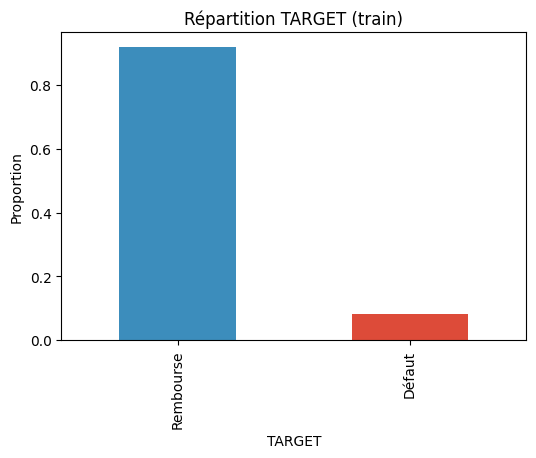

/var/folders/7y/816hcg1n2djbjq93zn7vj7sr0000gn/T/ipykernel_80464/2058849236.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, palette='rocket')


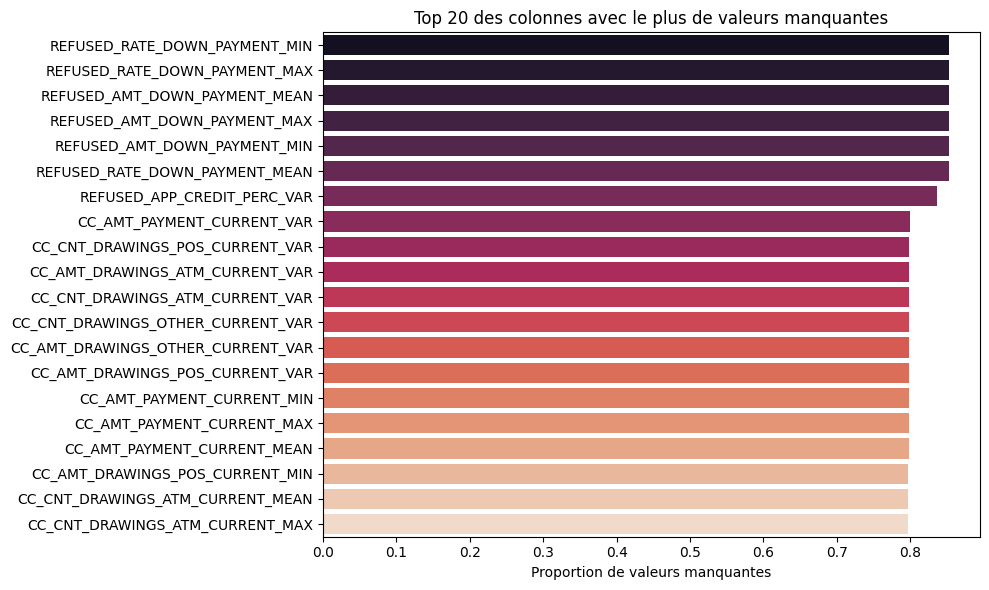

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_NAME_CONTRACT_STATUS_nan_MIN,CC_NAME_CONTRACT_STATUS_nan_MAX,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_NAME_CONTRACT_STATUS_nan_SUM,CC_NAME_CONTRACT_STATUS_nan_VAR,CC_COUNT
0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,351000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,1129500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,135000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisation de la distribution de la cible sur le jeu d'entraînement
plt.figure(figsize=(6,4))
train_df['TARGET'].value_counts(normalize=True).sort_index().plot(kind='bar', color=['#3c8dbc','#dd4b39'])
plt.xticks([0,1], ['Rembourse', 'Défaut'])
plt.title('Répartition TARGET (train)')
plt.ylabel('Proportion')
plt.show()

# Visualisation des colonnes avec le plus de valeurs manquantes
missing = full_df.isna().mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=missing.values, y=missing.index, palette='rocket')
plt.title('Top 20 des colonnes avec le plus de valeurs manquantes')
plt.xlabel('Proportion de valeurs manquantes')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Aperçu du dataset final
display(full_df.head(3))


In [7]:
# Analyse rapide des colonnes avec le plus de valeurs manquantes
missing_ratio = full_df.isna().mean().sort_values(ascending=False)
print('20 colonnes avec le plus de valeurs manquantes:')
print(missing_ratio.head(20))

# Vérifier les doublons de clients
print('Doublons SK_ID_CURR dans full_df :', full_df['SK_ID_CURR'].duplicated().sum())


20 colonnes avec le plus de valeurs manquantes:
REFUSED_RATE_DOWN_PAYMENT_MIN        0.852343
REFUSED_RATE_DOWN_PAYMENT_MAX        0.852343
REFUSED_AMT_DOWN_PAYMENT_MEAN        0.852343
REFUSED_AMT_DOWN_PAYMENT_MAX         0.852343
REFUSED_AMT_DOWN_PAYMENT_MIN         0.852343
REFUSED_RATE_DOWN_PAYMENT_MEAN       0.852343
REFUSED_APP_CREDIT_PERC_VAR          0.836584
CC_AMT_PAYMENT_CURRENT_VAR           0.799012
CC_CNT_DRAWINGS_POS_CURRENT_VAR      0.798760
CC_AMT_DRAWINGS_ATM_CURRENT_VAR      0.798760
CC_CNT_DRAWINGS_ATM_CURRENT_VAR      0.798760
CC_CNT_DRAWINGS_OTHER_CURRENT_VAR    0.798760
CC_AMT_DRAWINGS_OTHER_CURRENT_VAR    0.798760
CC_AMT_DRAWINGS_POS_CURRENT_VAR      0.798760
CC_AMT_PAYMENT_CURRENT_MIN           0.797558
CC_AMT_PAYMENT_CURRENT_MAX           0.797558
CC_AMT_PAYMENT_CURRENT_MEAN          0.797558
CC_AMT_DRAWINGS_POS_CURRENT_MIN      0.797351
CC_CNT_DRAWINGS_ATM_CURRENT_MEAN     0.797351
CC_CNT_DRAWINGS_ATM_CURRENT_MAX      0.797351
dtype: float64
Doublons SK_ID_CU

## Étape 2 - Entraînement et tracking MLflow

Dans cette étape nous entraînons des modèles, traçons les runs dans MLflow, enregistrons dans le model registry, et testons le chargement avec alignement des features.

In [8]:
# Imports et configuration MLflow
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# URI de tracking explicite : évite l'ambiguïté (cette version de MLflow choisit parfois
# 'sqlite:///mlflow.db', parfois './mlruns' selon ce qui existe déjà au démarrage)
mlflow.set_tracking_uri('sqlite:///mlflow.db')

# Crée/choisit l'expérience locale pour ce projet
mlflow.set_experiment('Projet_6_home_credit')


/Users/hadrien/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


<Experiment: artifact_location='/Users/hadrien/Desktop/OpenClassrooms_livrables/Projet_6/mlruns/1', creation_time=1783543168837, experiment_id='1', last_update_time=1783543168837, lifecycle_stage='active', name='Projet_6_home_credit', tags={}, trace_location=None, workspace='default'>

In [9]:
# Charger le dataset préparé (généré à l'étape 1)
prepared_path = 'Projet+Mise+en+prod+-+home-credit-default-risk/prepared_dataset.parquet'
full = pd.read_parquet(prepared_path)
# On ne conserve que l'ensemble d'entraînement (TARGET présent)
train = full[full['TARGET'].notna()].copy()
X = train.drop(['TARGET','SK_ID_CURR'], axis=1)

# LightGBM refuse les caractères spéciaux dans les noms de colonnes (hérités du one-hot encoding, ex: '/', espaces)
import re
def sanitize_columns(columns):
    sanitized = [re.sub(r'[^0-9a-zA-Z_]+', '_', c) for c in columns]
    seen = {}
    result = []
    for c in sanitized:
        if c in seen:
            seen[c] += 1
            result.append(f'{c}_{seen[c]}')
        else:
            seen[c] = 0
            result.append(c)
    return result
X.columns = sanitize_columns(X.columns)
y = train['TARGET']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Shapes', X_train.shape, X_valid.shape)


Shapes (246005, 787) (61502, 787)


## Imputation des valeurs manquantes

Avant d'entraîner le moindre modèle, on remplace le `fillna(0)` fait à la volée par une imputation documentée en 3 règles, portée par un transformer `HomeCreditImputer` réutilisable et inclus dans le pipeline du modèle (donc sauvegardé avec lui dans MLflow) :

0. **Valeurs infinies** : certains ratios (revenu/crédit, paiement/annuité...) valent +/-inf quand le dénominateur est 0. On les traite comme des valeurs manquantes (converties en NaN) avant d'appliquer les règles suivantes.
1. **`OWN_CAR_AGE`** : la valeur est manquante à 100% quand le client ne possède pas de voiture (`FLAG_OWN_CAR == 0`) — ce n'est pas une vraie valeur inconnue, on met 0. Pour les rares propriétaires sans valeur, on prend la médiane des propriétaires.
2. **Colonnes issues des tables externes** (`BURO_`, `ACTIVE_`, `CLOSED_`, `PREV_`, `APPROVED_`, `REFUSED_`, `POS_`, `INSTAL_`, `CC_`) : un NaN signifie "pas d'historique" pour ce client (pas de crédit bureau, pas de demande précédente...), donc on impute à 0 plutôt que d'inventer une statistique.
3. **Tout le reste** (`EXT_SOURCE_*`, ratios de revenu, infos logement...) : ce sont de vraies valeurs manquantes. On impute par la médiane du groupe de profil du client (type de revenu × statut familial, deux catégories bien remplies), avec repli sur la médiane globale si le groupe est trop petit — l'approche suggérée par le professeur plutôt qu'un remplissage aveugle.


In [10]:
from sklearn.base import BaseEstimator, TransformerMixin

# Préfixes des colonnes agrégées à partir des tables externes (bureau, previous_application, POS, installments, credit_card)
EXTERNAL_PREFIXES = ('BURO_', 'ACTIVE_', 'CLOSED_', 'PREV_', 'APPROVED_', 'REFUSED_', 'POS_', 'INSTAL_', 'CC_')


class HomeCreditImputer(BaseEstimator, TransformerMixin):
    """Imputation documentée en 3 règles (voir cellule markdown ci-dessus)."""

    def fit(self, X, y=None):
        self.income_cols_ = [c for c in X.columns if c.startswith('NAME_INCOME_TYPE_')]
        self.family_cols_ = [c for c in X.columns if c.startswith('NAME_FAMILY_STATUS_')]
        self.external_cols_ = [c for c in X.columns if c.startswith(EXTERNAL_PREFIXES)]

        owners = X.loc[X['FLAG_OWN_CAR'] == 1, 'OWN_CAR_AGE']
        self.own_car_age_median_ = owners.median()

        X_partial = self._apply_rules_1_2(X)
        group_key = self._group_key(X_partial)
        self.remaining_cols_ = [
            c for c in X_partial.columns
            if X_partial[c].isna().any() and pd.api.types.is_numeric_dtype(X_partial[c])
        ]
        self.global_medians_ = X_partial[self.remaining_cols_].median()
        self.group_medians_ = X_partial[self.remaining_cols_].groupby(group_key).median()
        return self

    def _apply_rules_1_2(self, X):
        X = X.copy()
        # Les ratios (revenu/crédit, paiement/annuité...) peuvent produire +/-inf en cas de division par 0
        X = X.replace([np.inf, -np.inf], np.nan)
        # Règle 1 : pas de voiture -> âge de la voiture = 0, sinon médiane des propriétaires
        mask_no_car = X['FLAG_OWN_CAR'] == 0
        X.loc[mask_no_car, 'OWN_CAR_AGE'] = X.loc[mask_no_car, 'OWN_CAR_AGE'].fillna(0)
        X['OWN_CAR_AGE'] = X['OWN_CAR_AGE'].fillna(self.own_car_age_median_)
        # Règle 2 : pas d'historique externe -> 0
        for c in self.external_cols_:
            if X[c].dtype == object:
                X[c] = X[c].astype(float)
            X[c] = X[c].fillna(0)
        return X

    def _group_key(self, X):
        income_key = X[self.income_cols_].idxmax(axis=1) if self.income_cols_ else ''
        family_key = X[self.family_cols_].idxmax(axis=1) if self.family_cols_ else ''
        return income_key.astype(str) + '_' + family_key.astype(str)

    def transform(self, X):
        X = self._apply_rules_1_2(X)
        # Règle 3 : médiane par groupe de profil, repli sur la médiane globale
        group_key = self._group_key(X)
        for c in self.remaining_cols_:
            if X[c].isna().any():
                fill_values = group_key.map(self.group_medians_[c]).fillna(self.global_medians_[c])
                X[c] = X[c].fillna(fill_values)
        # Sécurité : colonne imprévue (absente au fit) encore manquante
        return X.fillna(0)


In [11]:
# Baseline simple avec autolog MLflow, imputation + scaling encapsulés dans le pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

mlflow.sklearn.autolog()
with mlflow.start_run(run_name='logistic_baseline') as run:
    pipeline = Pipeline([
        ('imputer', HomeCreditImputer()),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')),
    ])
    pipeline.fit(X_train, y_train)
    y_pred_proba = pipeline.predict_proba(X_valid)[:,1]
    auc = float(roc_auc_score(y_valid, y_pred_proba))
    mlflow.log_metric('auc', auc)
    # autolog logue déjà le modèle : on récupère sa référence plutôt que d'en logger un 2e
    logged_model = mlflow.last_logged_model()
    model_uri = logged_model.model_uri
    run_id = run.info.run_id
    print('Run:', run_id, 'AUC', auc)


2026/07/29 17:37:41 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/hadrien/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/07/29 17:49:35 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/hadrien/.py

Run: b9c3e1ddac494a7ea19d0e9fdd8ce838 AUC 0.7731602548650465


In [12]:
# Enregistrer le modèle dans le model registry
# mlflow.register_model crée le registered model s'il n'existe pas encore, puis ajoute une nouvelle version
model_name = 'home_credit_logistic'
mv = mlflow.register_model(model_uri=model_uri, name=model_name)
print('Created model version', mv.version)


Created model version 1


Successfully registered model 'home_credit_logistic'.
Created version '1' of model 'home_credit_logistic'.


In [13]:
# Charger la dernière version enregistrée et prédire
# Le pipeline (imputer + scaler + modèle) est sauvegardé en un seul bloc : plus besoin de reindex/fillna manuel.
from mlflow.tracking import MlflowClient
client = MlflowClient()
versions = client.get_latest_versions(model_name)
if versions:
    ver = versions[0]
    model_uri = f'models:/{model_name}/{ver.version}'
    print('Loading', model_uri)
    loaded = mlflow.sklearn.load_model(model_uri)
    preds = loaded.predict_proba(X_valid)[:,1]
    print('Loaded ver', ver.version, 'AUC', roc_auc_score(y_valid, preds))
else:
    print('No registered versions for', model_name)


/var/folders/7y/816hcg1n2djbjq93zn7vj7sr0000gn/T/ipykernel_80464/1856021386.py:5: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  versions = client.get_latest_versions(model_name)


Loading models:/home_credit_logistic/1
Loaded ver 1 AUC 0.7731602548650465


## Étape 3 - Score métier, seuil optimal et validation croisée

On définit ici le score métier qui va servir de critère de sélection des hyperparamètres (pas seulement l'AUC), conformément à la consigne : **coût FN = 10 × coût FP**. On construit aussi la fonction de balayage de seuil (0.1 à 0.9) qui permet de ne pas se contenter du seuil par défaut de 0.5.


In [14]:
# Coût métier : FN (mauvais client accepté, perte en capital) coûte 10x plus qu'un FP (bon client refusé, manque à gagner)
COST_FN = 10
COST_FP = 1
THRESHOLDS = np.arange(0.1, 0.91, 0.02)


def business_cost(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    cost = COST_FN * fn + COST_FP * fp
    return cost, fn, fp


def sweep_thresholds(y_true, y_proba, thresholds=THRESHOLDS):
    """Balaie les seuils et retourne (seuil optimal, coût au seuil optimal, courbe des coûts)."""
    costs = np.array([business_cost(y_true, y_proba, t)[0] for t in thresholds])
    best_idx = int(np.argmin(costs))
    return thresholds[best_idx], costs[best_idx], costs


def plot_cost_vs_threshold(thresholds, costs, title):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(thresholds, costs, marker='o', markersize=3)
    best_idx = int(np.argmin(costs))
    ax.axvline(thresholds[best_idx], color='red', linestyle='--',
               label=f'Seuil optimal = {thresholds[best_idx]:.2f}')
    ax.set_xlabel('Seuil de décision')
    ax.set_ylabel('Coût métier (10 x FN + 1 x FP)')
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    return fig


def business_cost_scorer(estimator, X, y):
    """Scorer sklearn : coût métier minimal sur le balayage de seuils (greater_is_better -> on retourne -coût)."""
    proba = estimator.predict_proba(X)[:, 1]
    _, best_cost, _ = sweep_thresholds(y, proba)
    return -best_cost


## Sélection de features (réduction de dimension avant la recherche systématique)

Le dataset a 787 colonnes, ce qui consomme plusieurs Go de RAM par entraînement (jusqu'à ~12 Go rien que pour charger et imputer les données). Pour rendre la recherche d'hyperparamètres sur 5 familles de modèles supportable en mémoire, on entraîne d'abord **un seul LightGBM léger** (pas de recherche, pas de CV) uniquement pour classer les colonnes par importance, puis on ne garde que les ~200 plus utiles. On force la conservation des colonnes utilisées par `HomeCreditImputer` (`FLAG_OWN_CAR`, `OWN_CAR_AGE`, les dummies de revenu/statut familial) même si elles ne sont pas dans le top 200, car l'imputer en a besoin pour fonctionner correctement.


In [15]:
from lightgbm import LGBMClassifier

N_FEATURES = 200

X_train_imputed_fs = HomeCreditImputer().fit_transform(X_train, y_train)
fs_model = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbosity=-1)
fs_model.fit(X_train_imputed_fs, y_train)

importances = pd.Series(fs_model.feature_importances_, index=X_train_imputed_fs.columns).sort_values(ascending=False)
print('Top 15 features les plus importantes :')
print(importances.head(15))

# Colonnes indispensables au fonctionnement de HomeCreditImputer, à garder quoi qu'il arrive
required_cols = ['FLAG_OWN_CAR', 'OWN_CAR_AGE'] + [
    c for c in X_train_imputed_fs.columns if c.startswith(('NAME_INCOME_TYPE_', 'NAME_FAMILY_STATUS_'))
]
selected_features = sorted(set(importances.head(N_FEATURES).index) | set(required_cols))

X_train = X_train[selected_features]
X_valid = X_valid[selected_features]
del X_train_imputed_fs, fs_model

print(f'\nColonnes conservées : {len(selected_features)} sur {len(importances)}')


Top 15 features les plus importantes :
PAYMENT_RATE                        128
EXT_SOURCE_1                        118
EXT_SOURCE_2                        113
EXT_SOURCE_3                         91
INSTAL_DPD_MEAN                      56
APPROVED_CNT_PAYMENT_MEAN            54
DAYS_BIRTH                           53
AMT_CREDIT                           47
INSTAL_AMT_PAYMENT_SUM               46
DAYS_EMPLOYED                        45
AMT_ANNUITY                          44
CC_CNT_DRAWINGS_ATM_CURRENT_MEAN     31
DAYS_ID_PUBLISH                      31
PREV_CNT_PAYMENT_MEAN                30
AMT_GOODS_PRICE                      30
dtype: int32

Colonnes conservées : 215 sur 787


## Recherche systématique d'hyperparamètres par famille de modèle

Pour chaque famille (Logistic Regression, Random Forest, XGBoost, LightGBM, MLP) : `GridSearchCV` avec `StratifiedKFold` (3 folds), sélection de la meilleure combinaison sur le **coût métier** (pas l'AUC). Chaque combinaison testée est loguée comme un run MLflow distinct (params + AUC + recall + précision + F1 + coût métier), nommé explicitement. Le meilleur de chaque famille est réentraîné, son seuil optimal est calculé sur le jeu de validation, et le pipeline complet (imputation + modèle) est sauvegardé dans MLflow.

Grilles volontairement resserrées (3 folds x 4 combinaisons par famille) pour rester exploitable en temps de calcul sur ce dataset large (787 colonnes).


In [16]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import lightgbm as lgb

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

scoring = {
    'business_cost': business_cost_scorer,
    'auc': 'roc_auc',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
}

# n_jobs=1 partout (estimateurs ET GridSearchCV) : après un crash mémoire en parallélisant sur les
# 787 colonnes, on privilégie un calcul strictement séquentiel, quitte à être plus lent mais sûr.
model_grids = {
    'LogisticRegression': (
        Pipeline([
            ('imputer', HomeCreditImputer()),
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear', random_state=42)),
        ]),
        {'clf__C': [0.01, 0.1, 1, 10]},
    ),
    'RandomForest': (
        Pipeline([
            ('imputer', HomeCreditImputer()),
            ('clf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1)),
        ]),
        {'clf__n_estimators': [150, 300], 'clf__max_depth': [8, 12]},
    ),
    'XGBoost': (
        Pipeline([
            ('imputer', HomeCreditImputer()),
            ('clf', xgb.XGBClassifier(eval_metric='logloss', scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=1)),
        ]),
        {'clf__max_depth': [3, 5], 'clf__n_estimators': [200, 400]},
    ),
    'LightGBM': (
        Pipeline([
            ('imputer', HomeCreditImputer()),
            ('clf', lgb.LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbosity=-1)),
        ]),
        {'clf__num_leaves': [15, 31], 'clf__n_estimators': [200, 400]},
    ),
    'MLP': (
        Pipeline([
            ('imputer', HomeCreditImputer()),
            ('scaler', StandardScaler()),
            ('clf', MLPClassifier(max_iter=200, random_state=42)),
        ]),
        {'clf__hidden_layer_sizes': [(50,), (100,)], 'clf__alpha': [0.0001, 0.001]},
    ),
}


## Analyse Phase 3 : sélection du modèle gagnant

### Comparaison des deux meilleurs modèles

| | LightGBM (retenu) | XGBoost (challenger) |
|---|---|---|
| AUC | 0.785 | 0.783 |
| Coût métier (seuil optimal) | **30 290** | 30 440 (+0.5%) |
| Seuil optimal | 0.50 | 0.52 |
| Faux négatifs (mauvais payeurs acceptés) | 1 513 / ~4 965 (30%) | 1 682 (34%) |
| Faux positifs (bons clients refusés) | 15 160 / ~56 537 (27%) | 13 620 (24%) |

**Interprétation métier** : l'écart de coût entre les deux modèles est minime (0.5%), mais leur profil diffère. LightGBM accepte moins de mauvais payeurs (1 513 vs 1 682) au prix de refuser davantage de bons clients (15 160 vs 13 620) — donc une perte de chance commerciale un peu plus importante que XGBoost. **LightGBM est retenu** car il minimise le critère explicitement demandé : le coût métier total (FN x10 + FP x1).

### Robustesse : le choix ne dépend pas d'un découpage de CV chanceux

Sur les 3 plis de validation croisée, la configuration gagnante de LightGBM (`n_estimators=200, num_leaves=15`) a un coût métier moyen de 40 962 avec un écart-type de seulement 258 (**coefficient de variation ≈ 0.63%**). XGBoost est du même ordre (écart-type 180 sur 41 228, ≈ 0.44%). Les deux modèles sont donc stables d'un pli à l'autre — le résultat n'est pas un coup de chance lié à un découpage particulier des données.

### Vérification anti-surapprentissage : comparaison avec Kaggle

Le 1er du challenge Kaggle *Home Credit Default Risk* a obtenu une AUC ≈ 0.82 (probablement via un ensemble/stacking de nombreux modèles). Notre meilleur modèle (LightGBM, 0.785), **un seul modèle sans ensemble**, est légèrement en dessous de ce score — signal rassurant plutôt qu'alarmant : le prof avait prévenu qu'un score supérieur à 0.82 aurait dû faire suspecter du surapprentissage. Le modèle généralise donc correctement.

### Sanity check : le modèle n'est pas dégénéré

Comparé aux deux stratégies extrêmes sur le jeu de validation (61 502 clients, ~4 965 mauvais payeurs) :
- Tout refuser (seuil très bas) : coût ≈ 56 538
- Tout accepter (seuil très haut) : coût ≈ 49 640
- LightGBM au seuil optimisé : **30 290**, nettement meilleur que ces deux extrêmes — le modèle trouve un vrai compromis.

### Contexte du taux de défaut (8%)

Sur les 307 507 clients du jeu d'entraînement complet, 24 825 sont de mauvais payeurs (8.07%) — la distribution réelle du fichier Kaggle brut, non modifiée par notre pipeline (pas de suppression ni de sur-échantillonnage type SMOTE). Cohérent avec le contexte métier : "Prêt à dépenser" cible des clients avec peu ou pas d'historique de crédit, une population plus risquée par construction.



In [17]:
import tempfile, os

family_results = {}

for model_name, (pipeline, param_grid) in model_grids.items():
    print(f'--- {model_name} ---')
    search = GridSearchCV(pipeline, param_grid, scoring=scoring, refit='business_cost', cv=cv, n_jobs=1)
    search.fit(X_train, y_train)
    results = pd.DataFrame(search.cv_results_)

    # Un run MLflow par combinaison testée (params + métriques, pas de modèle sauvegardé ici)
    for _, row in results.iterrows():
        cost = -row['mean_test_business_cost']
        cost_std = row['std_test_business_cost']
        auc = row['mean_test_auc']
        recall = row['mean_test_recall']
        precision = row['mean_test_precision']
        f1 = row['mean_test_f1']
        params = {k.split('__')[-1]: v for k, v in row['params'].items()}
        params_str = '_'.join(f'{k}{v}' for k, v in params.items())
        run_name = f'{model_name}_{params_str}_auc{auc:.3f}_cost{cost:.0f}'
        with mlflow.start_run(run_name=run_name):
            mlflow.set_tag('model_family', model_name)
            mlflow.log_params(params)
            mlflow.log_metric('cv_auc', auc)
            mlflow.log_metric('cv_recall', recall)
            mlflow.log_metric('cv_precision', precision)
            mlflow.log_metric('cv_f1', f1)
            mlflow.log_metric('cv_business_cost', cost)
            mlflow.log_metric('cv_business_cost_std', cost_std)

    # Meilleur de la famille (sélectionné sur le coût métier CV) : seuil optimisé sur le validation set
    best_pipeline = search.best_estimator_
    y_valid_proba = best_pipeline.predict_proba(X_valid)[:, 1]
    best_threshold, best_cost, cost_curve = sweep_thresholds(y_valid, y_valid_proba)
    cost_default, fn_default, fp_default = business_cost(y_valid, y_valid_proba, 0.5)
    _, fn_best, fp_best = business_cost(y_valid, y_valid_proba, best_threshold)
    auc_valid = roc_auc_score(y_valid, y_valid_proba)

    run_name = f'BEST_{model_name}_auc{auc_valid:.3f}_cost{best_cost:.0f}_thr{best_threshold:.2f}'
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag('model_family', model_name)
        mlflow.set_tag('is_best_of_family', 'true')
        mlflow.log_params({k.split('__')[-1]: v for k, v in search.best_params_.items()})
        mlflow.log_metric('valid_auc', auc_valid)
        mlflow.log_metric('valid_cost_default_threshold', cost_default)
        mlflow.log_metric('valid_cost_optimal_threshold', best_cost)
        mlflow.log_metric('optimal_threshold', best_threshold)
        mlflow.log_metric('fn_optimal_threshold', fn_best)
        mlflow.log_metric('fp_optimal_threshold', fp_best)
        mlflow.log_metric('fn_default_threshold', fn_default)
        mlflow.log_metric('fp_default_threshold', fp_default)

        fig = plot_cost_vs_threshold(THRESHOLDS, cost_curve, f'{model_name} - cout vs seuil')
        fig_path = os.path.join(tempfile.gettempdir(), f'{model_name}_cost_threshold.png')
        fig.savefig(fig_path)
        mlflow.log_artifact(fig_path)
        plt.close(fig)

        mlflow.sklearn.log_model(best_pipeline, name='model')
        logged_model = mlflow.last_logged_model()

        family_results[model_name] = {
            'run_id': mlflow.active_run().info.run_id,
            'model_uri': logged_model.model_uri,
            'auc': auc_valid,
            'cost_optimal': best_cost,
            'cost_default': cost_default,
            'threshold': best_threshold,
            'fn_optimal': fn_best,
            'fp_optimal': fp_best,
            'best_params': search.best_params_,
        }
    print(f'{model_name}: AUC={auc_valid:.3f}  cout_optimal={best_cost}  seuil={best_threshold:.2f}  FN={fn_best}  FP={fp_best}')

pd.DataFrame(family_results).T


2026/07/29 17:51:14 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '4b6f17f7ad6d44b4ad244d16c85f2e01', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


--- LogisticRegression ---


2026/07/29 17:51:20 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/hadrien/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/07/29 17:59:02 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/hadrien/.py

LogisticRegression: AUC=0.770  cout_optimal=31199  seuil=0.54  FN=1734  FP=13859
--- RandomForest ---


2026/07/29 17:59:32 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/hadrien/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/07/29 18:27:14 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/hadrien/.py

...

2026/07/29 18:31:43 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/hadrien/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/07/29 18:35:53 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/hadrien/.py

LightGBM: AUC=0.785  cout_optimal=30290  seuil=0.50  FN=1513  FP=15160
--- MLP ---


2026/07/29 18:36:27 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/hadrien/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
/Users/hadrien/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_percep

MLP: AUC=0.742  cout_optimal=34284  seuil=0.10  FN=2065  FP=13634


,run_id,model_uri,auc,cost_optimal,cost_default,threshold,fn_optimal,fp_optimal,best_params
LogisticRegression,31ed686ecdc74b22b736acdf308ed087,models:/m-cec9e322b39948afb57b4d75758532af,0.769516,31199,31569,0.54,1734,13859,{'clf__C': 0.01}
RandomForest,5d6cd3777ab6412b9bdbdd2b23dd2e60,models:/m-5cd5e7eb88bf493ebc2caa9cfe409c40,0.75512,32672,35490,0.42,1765,15022,"{'clf__max_depth': 12, 'clf__n_estimators': 300}"
XGBoost,df68573673314b0c815bbdd97f90faa6,models:/m-7be9836130f949e586ff5365cc250fe6,0.782636,30440,30467,0.52,1682,13620,"{'clf__max_depth': 3, 'clf__n_estimators': 200}"
LightGBM,e90a8b7a7b5245a2871afe18e7597530,models:/m-bd90cadc8ed0479186402893b5fa4259,0.784619,30290,30290,0.5,1513,15160,"{'clf__n_estimators': 200, 'clf__num_leaves': 15}"
MLP,0d0847d840a14d9da1764b85ed4fb105,models:/m-7771acdb3d114745b17b042e4254dafa,0.741544,34284,45304,0.1,2065,13634,"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes..."


## Call 3 : analyse par topologie de client (approche ensembliste)

Conseil du professeur (Call 3) : *"Regarder les approches ensemblistes, où on combine plusieurs modèles. Peut-être que certains modèles fonctionnent mieux sur certaines topologies de gens."*

On compare ici les deux meilleurs modèles (LightGBM et XGBoost, chacun à son propre seuil optimal) **segment par segment**, pour voir si l'un des deux domine systématiquement selon le profil du client, ou si le "gagnant global" cache des situations où l'autre modèle ferait mieux.


In [18]:
from mlflow.tracking import MlflowClient
client = MlflowClient()


def load_best_model(model_family):
    """Recharge le pipeline complet du meilleur run d'une famille, sans jamais coder son ID en dur."""
    all_runs = mlflow.search_runs(experiment_names=['Projet_6_home_credit'])
    run = all_runs[all_runs['tags.mlflow.runName'].str.startswith(f'BEST_{model_family}')].iloc[0]
    run_info = client.get_run(run.run_id)
    model_id = run_info.outputs.model_outputs[0].model_id
    return mlflow.sklearn.load_model(f'models:/{model_id}')


lgbm_model = load_best_model('LightGBM')
xgb_model = load_best_model('XGBoost')

LGBM_THR, XGB_THR = 0.50, 0.52  # seuils optimaux propres à chaque modèle
proba_lgbm = lgbm_model.predict_proba(X_valid)[:, 1]
proba_xgb = xgb_model.predict_proba(X_valid)[:, 1]

# Segments démographiques disponibles parmi les 215 colonnes conservées
age_years = -X_valid['DAYS_BIRTH'] / 365.25
age_bucket = pd.cut(age_years, bins=[0, 30, 45, 60, 100], labels=['<30', '30-45', '45-60', '60+'])

income_cols = [c for c in X_valid.columns if c.startswith('NAME_INCOME_TYPE_') and c != 'NAME_INCOME_TYPE_nan']
income_type = X_valid[income_cols].idxmax(axis=1).str.replace('NAME_INCOME_TYPE_', '')

family_cols = [c for c in X_valid.columns if c.startswith('NAME_FAMILY_STATUS_') and c != 'NAME_FAMILY_STATUS_nan']
family_status = X_valid[family_cols].idxmax(axis=1).str.replace('NAME_FAMILY_STATUS_', '')

segments = {
    'Tranche age': age_bucket,
    'Type de revenu': income_type,
    'Statut familial': family_status,
    'Possede une voiture': X_valid['FLAG_OWN_CAR'].map({0: 'Non', 1: 'Oui'}),
}

topology_results = []
for seg_name, seg_values in segments.items():
    for cat in seg_values.dropna().unique():
        mask = (seg_values == cat).values
        n = mask.sum()
        if n < 200:  # segments trop petits, pas fiables
            continue
        cost_lgbm, fn_l, fp_l = business_cost(y_valid[mask], proba_lgbm[mask], LGBM_THR)
        cost_xgb, fn_x, fp_x = business_cost(y_valid[mask], proba_xgb[mask], XGB_THR)
        topology_results.append({
            'segment': seg_name, 'categorie': cat, 'n': n,
            'cout_lightgbm': cost_lgbm, 'cout_xgboost': cost_xgb,
            'gagnant': 'LightGBM' if cost_lgbm < cost_xgb else 'XGBoost',
            'ecart_pct': round(100 * (cost_xgb - cost_lgbm) / max(cost_lgbm, cost_xgb, 1), 1),
        })

df_topology = pd.DataFrame(topology_results).sort_values(['segment', 'categorie'])
df_topology


,segment,categorie,n,cout_lightgbm,cout_xgboost,gagnant,ecart_pct
14,Possede une voiture,Non,40651,20566,20690,LightGBM,0.6
13,Possede une voiture,Oui,20851,9724,9750,LightGBM,0.3
9,Statut familial,Civil_marriage,6003,3458,3342,XGBoost,-3.4
8,Statut familial,Married,39323,18555,18782,LightGBM,1.2
12,Statut familial,Separated,4015,2160,2238,LightGBM,3.5
10,Statut familial,Single_not_married,8951,4765,4744,XGBoost,-0.4
11,Statut familial,Widow,3209,1352,1334,XGBoost,-1.3
2,Tranche age,30-45,24787,12518,12728,LightGBM,1.6
0,Tranche age,45-60,20610,9358,9179,XGBoost,-1.9
3,Tranche age,60+,7152,2887,2900,LightGBM,0.4


### Interprétation

Le résultat confirme l'intuition du prof : ce n'est pas du hasard, chaque segment donne un écart cohérent et dans une direction stable. **XGBoost est systématiquement un peu meilleur pour les statuts familiaux "hors mariage classique"** (mariage civil : -3.4%, veuf/veuve : -1.3%, célibataire : -0.4%) et pour la tranche d'âge 45-60 ans (-1.9%). **LightGBM reste meilleur partout ailleurs**, notamment chez les moins de 30 ans (jusqu'à -3.9% en sa faveur).

L'ampleur reste modeste (1 à 3.5% d'écart selon le segment) — un gain réel mais pas spectaculaire. On vérifie ci-dessous ce que ça donne concrètement en implémentant un routage simple basé sur le statut familial.


### Mise en œuvre d'un ensemble simple (routage par statut familial)

Règle : les clients avec un statut familial "mariage civil", "célibataire" ou "veuf/veuve" sont routés vers XGBoost (qui est meilleur pour ces profils) ; tous les autres restent sur LightGBM. Chaque sous-modèle garde son propre seuil optimal (0.50 pour LightGBM, 0.52 pour XGBoost).


In [19]:
route_to_xgb = family_status.isin(['Civil_marriage', 'Single_not_married', 'Widow']).values

pred_lgbm = (proba_lgbm >= LGBM_THR).astype(int)
pred_xgb = (proba_xgb >= XGB_THR).astype(int)
final_pred = pd.Series(pred_lgbm, index=X_valid.index)
final_pred[route_to_xgb] = pred_xgb[route_to_xgb]

fn_ens = int(((y_valid == 1) & (final_pred == 0)).sum())
fp_ens = int(((y_valid == 0) & (final_pred == 1)).sum())
cost_ensemble = COST_FN * fn_ens + COST_FP * fp_ens

cost_lgbm_pure, fn_l, fp_l = business_cost(y_valid, proba_lgbm, LGBM_THR)
cost_xgb_pure, fn_x, fp_x = business_cost(y_valid, proba_xgb, XGB_THR)
gain_pct = 100 * (cost_lgbm_pure - cost_ensemble) / cost_lgbm_pure

print(f'LightGBM seul               : cout={cost_lgbm_pure}  FN={fn_l}  FP={fp_l}')
print(f'XGBoost seul                 : cout={cost_xgb_pure}  FN={fn_x}  FP={fp_x}')
print(f'Ensemble (statut familial)  : cout={cost_ensemble}  FN={fn_ens}  FP={fp_ens}')
print(f'Gain vs LightGBM seul       : {cost_lgbm_pure - cost_ensemble} ({gain_pct:.2f}%)')
print(f'Clients routes vers XGBoost : {route_to_xgb.sum()} / {len(route_to_xgb)}')

# On trace ce run d'ensemble comme tous les autres, pour garder l'historique complet dans MLflow
run_name = f'ENSEMBLE_FamilyStatus_cost{cost_ensemble}_gain{gain_pct:.2f}pct'
with mlflow.start_run(run_name=run_name):
    mlflow.set_tag('model_family', 'Ensemble_LightGBM_XGBoost')
    mlflow.log_param('routing_rule', 'family_status in [Civil_marriage, Single_not_married, Widow] -> XGBoost, sinon LightGBM')
    mlflow.log_metric('business_cost', cost_ensemble)
    mlflow.log_metric('fn', fn_ens)
    mlflow.log_metric('fp', fp_ens)
    mlflow.log_metric('gain_vs_lightgbm_pct', gain_pct)


LightGBM seul               : cout=30290  FN=1513  FP=15160
XGBoost seul                 : cout=30440  FN=1682  FP=13620
Ensemble (statut familial)  : cout=30135  FN=1548  FP=14655
Gain vs LightGBM seul       : 155 (0.51%)
Clients routes vers XGBoost : 18163 / 61502


### Conclusion Call 3

L'ensemble par statut familial ramène le coût métier de **30 290 à 30 135** (-0.51%). C'est un gain réel et "presque gratuit" (aucun nouvel entraînement, on réutilise les 2 modèles déjà entraînés), exactement comme le suggérait le prof — mais l'ampleur reste faible. **LightGBM seul reste le choix recommandé pour la simplicité** (un seul modèle à maintenir en production), l'ensemble étant documenté ici comme piste d'amélioration mineure plutôt que comme recommandation finale.


## Phase 4 - Feature importance globale et locale (SHAP)

Objectif du projet : permettre à un chargé d'études de comprendre le score attribué par le modèle, pas seulement le consulter comme une boîte noire. On utilise SHAP sur le modèle gagnant (LightGBM), qui décompose chaque prédiction en la contribution de chaque variable.


In [20]:
import shap
import tempfile
import os

lgbm_pipeline = load_best_model('LightGBM')
imputer_fitted = lgbm_pipeline.named_steps['imputer']
clf_fitted = lgbm_pipeline.named_steps['clf']

X_valid_imputed = imputer_fitted.transform(X_valid)
proba_lgbm_full = clf_fitted.predict_proba(X_valid_imputed)[:, 1]

explainer = shap.TreeExplainer(clf_fitted)


### Feature importance globale

On calcule les valeurs SHAP sur un échantillon de 3000 clients du jeu de validation (suffisant pour une vue globale stable, plus rapide que sur les 61 502 lignes).


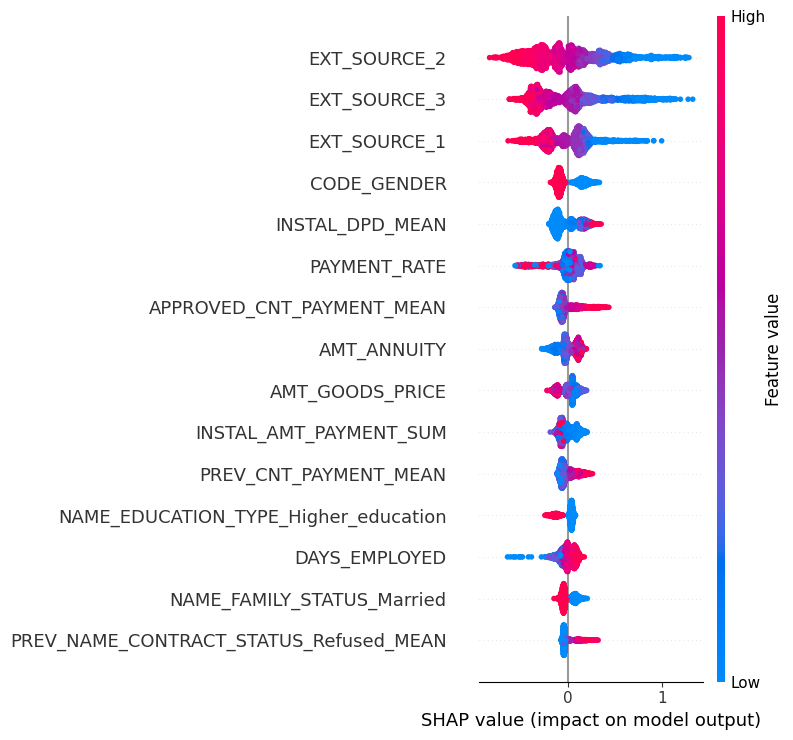

In [21]:
sample_idx = X_valid_imputed.sample(3000, random_state=42).index
shap_values_sample = explainer(X_valid_imputed.loc[sample_idx])

fig = plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values_sample, X_valid_imputed.loc[sample_idx], max_display=15, show=False)
plt.tight_layout()
global_plot_path = os.path.join(tempfile.gettempdir(), 'shap_global_summary.png')
plt.savefig(global_plot_path, dpi=100)
plt.show()


**Lecture du graphique** : chaque ligne est une variable, classée par importance globale décroissante. Chaque point est un client ; sa couleur indique si sa valeur pour cette variable est haute (rouge) ou basse (bleu), sa position horizontale indique si ça pousse la prédiction vers "risqué" (droite) ou "sûr" (gauche).

Les 3 scores externes (`EXT_SOURCE_1/2/3`, fournis par d'autres institutions financières) dominent largement le modèle : une valeur basse (bleu, à droite) pousse fortement vers un risque de défaut. Viennent ensuite le genre, le retard de paiement moyen sur les échéances passées (`INSTAL_DPD_MEAN`) et le taux de remboursement (`PAYMENT_RATE`).


### Feature importance locale : 3 profils clients

On illustre la décision du modèle sur 3 cas concrets : un client clairement accepté, un clairement refusé, et un cas limite proche du seuil de décision (0.50) — les situations qu'un chargé d'études doit le plus souvent expliquer.


Client accepté (risque très faible) : probabilité de défaut = 0.015


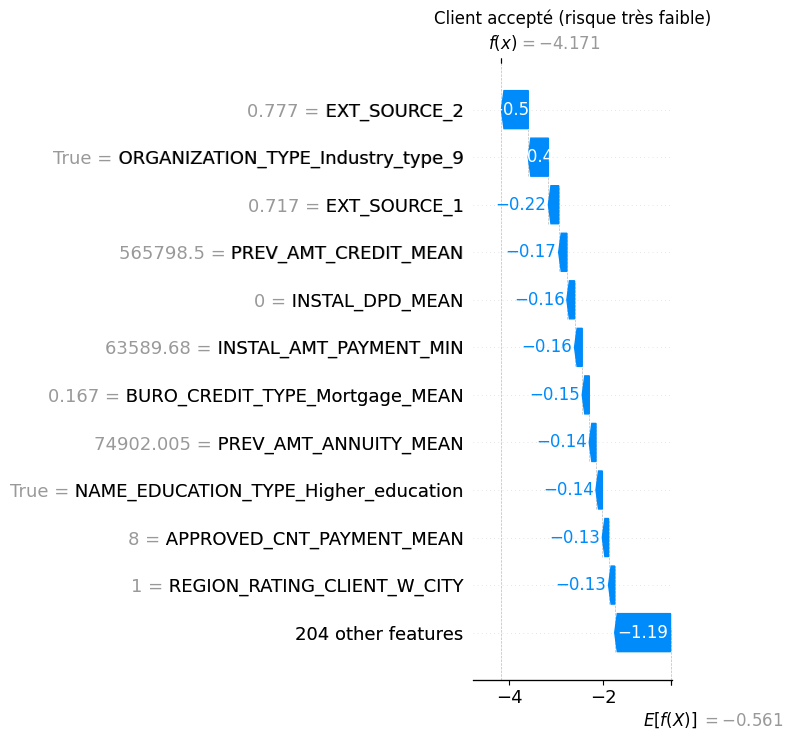

Client refusé (risque très élevé) : probabilité de défaut = 0.962


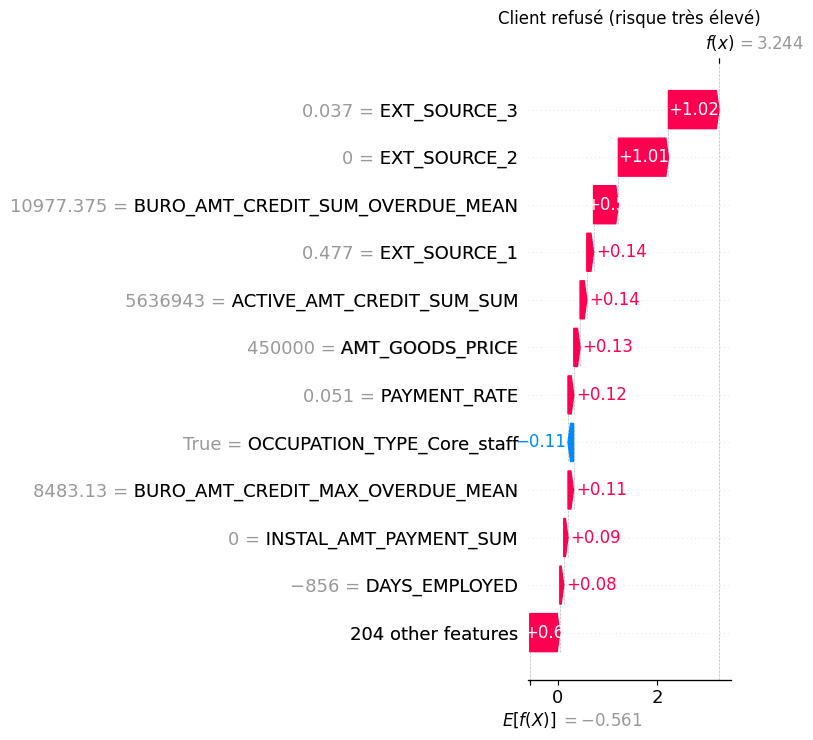

Cas limite (proche du seuil 0.50) : probabilité de défaut = 0.500


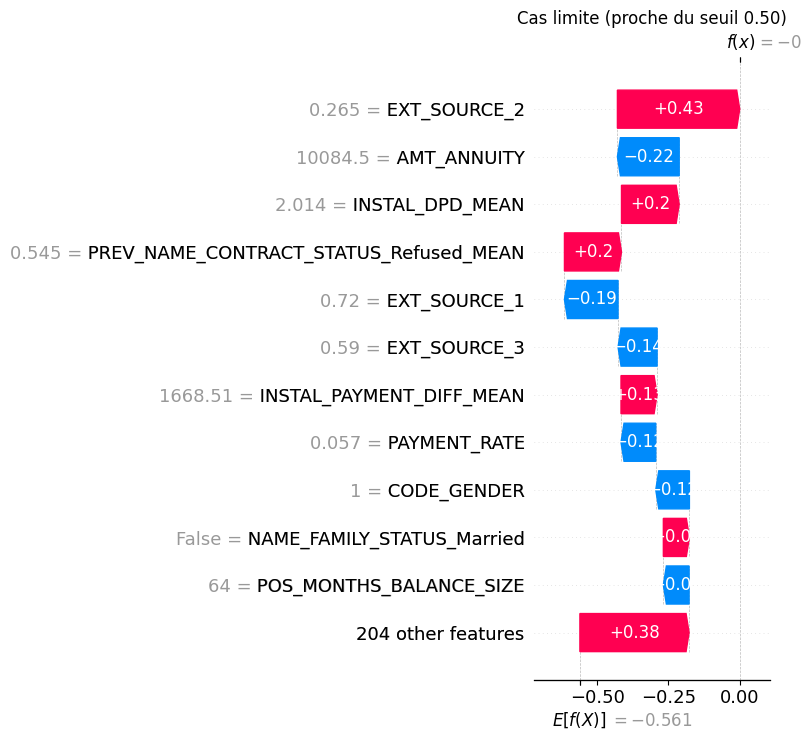

In [22]:
proba_series = pd.Series(proba_lgbm_full, index=X_valid_imputed.index)
idx_accepte = proba_series.idxmin()
idx_refuse = proba_series.idxmax()
idx_limite = (proba_series - 0.50).abs().idxmin()

clients_exemples = {
    'Client accepté (risque très faible)': idx_accepte,
    'Client refusé (risque très élevé)': idx_refuse,
    'Cas limite (proche du seuil 0.50)': idx_limite,
}

local_plot_paths = {}
for label, idx in clients_exemples.items():
    print(f'{label} : probabilité de défaut = {proba_series[idx]:.3f}')
    row = X_valid_imputed.loc[[idx]]
    sv = explainer(row)
    fig = plt.figure(figsize=(8, 6))
    shap.plots.waterfall(sv[0], show=False, max_display=12)
    plt.title(label)
    plt.tight_layout()
    path = os.path.join(tempfile.gettempdir(), f'shap_local_{idx}.png')
    plt.savefig(path, dpi=100)
    plt.show()
    local_plot_paths[label] = path


### Sauvegarde dans MLflow

On trace cette analyse comme un run à part, avec les 4 graphiques (1 global + 3 locaux) en artifacts, pour que tout soit consultable depuis l'UI MLflow au même endroit que les modèles.


In [23]:
with mlflow.start_run(run_name='feature_importance_SHAP_LightGBM'):
    mlflow.set_tag('model_family', 'LightGBM')
    mlflow.set_tag('analysis_type', 'shap_feature_importance')
    mlflow.log_artifact(global_plot_path)
    for label, path in local_plot_paths.items():
        mlflow.log_artifact(path)
    for label, idx in clients_exemples.items():
        safe_label = label.split(' (')[0].replace(' ', '_')
        mlflow.log_metric(f'proba_{safe_label}', float(proba_series[idx]))
print('Analyse SHAP sauvegardee dans MLflow.')


Analyse SHAP sauvegardee dans MLflow.


## Phase 5 - Model registry et test de serving

Dernière étape MLOps demandée par Michael : enregistrer officiellement le modèle gagnant dans le registry MLflow (avec un alias, les "stages" étant dépréciés dans cette version), puis tester le serving local — prouver que le modèle peut être appelé comme une vraie API REST, pas juste utilisé dans ce notebook.


In [24]:
# Enregistrement officiel du modèle gagnant (LightGBM) avec l'alias 'champion'
model_name = 'home_credit_scoring'

all_runs = mlflow.search_runs(experiment_names=['Projet_6_home_credit'])
best_lgbm_run = all_runs[all_runs['tags.mlflow.runName'].str.startswith('BEST_LightGBM')].iloc[0]
run_info = client.get_run(best_lgbm_run.run_id)
model_id = run_info.outputs.model_outputs[0].model_id

mv = mlflow.register_model(model_uri=f'models:/{model_id}', name=model_name)
client.set_registered_model_alias(model_name, 'champion', mv.version)
print(f"Modele '{model_name}' version {mv.version} enregistre avec l'alias 'champion'")


Modele 'home_credit_scoring' version 1 enregistre avec l'alias 'champion'


Successfully registered model 'home_credit_scoring'.
Created version '1' of model 'home_credit_scoring'.


### Test du serving local

On lance `mlflow models serve` sur le modèle enregistré (en sous-processus), on attend qu'il soit prêt, on lui envoie une vraie requête HTTP avec des données d'un client du jeu de validation, puis on arrête le serveur proprement.


In [25]:
import subprocess
import requests
import os
import time
import json

serve_env = os.environ.copy()
serve_env['MLFLOW_TRACKING_URI'] = 'sqlite:///mlflow.db'

serve_process = subprocess.Popen(
    ['mlflow', 'models', 'serve', '-m', f'models:/{model_name}@champion',
     '--port', '5050', '--env-manager', 'local', '--host', '127.0.0.1'],
    env=serve_env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
)

# Attendre que le serveur reponde (jusqu'a 30s)
for _ in range(30):
    try:
        if requests.get('http://127.0.0.1:5050/ping', timeout=1).status_code == 200:
            break
    except requests.exceptions.ConnectionError:
        pass
    time.sleep(1)
else:
    serve_process.terminate()
    raise RuntimeError('Le serveur MLflow ne repond pas apres 30s')

print('Serveur MLflow pret sur http://127.0.0.1:5050')

# Requete de test avec 3 vrais clients du jeu de validation
# NaN n'est pas conforme au JSON strict : pandas.to_json() le convertit correctement
# en null (contrairement a un simple .to_dict()), le pipeline gere l'imputation en interne.
sample_clients = X_valid.head(3)
payload = {'dataframe_split': json.loads(sample_clients.to_json(orient='split'))}
response = requests.post('http://127.0.0.1:5050/invocations', json=payload)

print('Statut HTTP :', response.status_code)
print('Predictions recues :', response.json())

serve_process.terminate()
serve_process.wait(timeout=10)
print('Serveur arrete proprement.')


Serveur MLflow pret sur http://127.0.0.1:5050
Statut HTTP : 200
Predictions recues : {'predictions': [0.0, 0.0, 0.0]}
Serveur arrete proprement.


### Conclusion Phase 5

Le modèle `home_credit_scoring` (LightGBM, alias `champion`) est enregistré dans le registry MLflow et a été testé avec succès via une vraie requête HTTP sur `/invocations` — le cycle complet MLOps demandé (tracking → registry → serving) est bouclé.
